In [16]:
import pandas as pd

# Load NAV history
df = pd.read_csv("/content/Cleaned_02_nav_history (1).csv")

# Sort properly
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["amfi_code", "date"])

# Daily returns
df["daily_return"] = df.groupby("amfi_code")["nav"].pct_change()

# Calculate VaR and CVaR for each scheme
def calculate_var_cvar(group):
    returns = group["daily_return"].dropna()

    var_95 = returns.quantile(0.05)

    tail_returns = returns[returns <= var_95]

    cvar_95 = tail_returns.mean()

    return pd.Series({
        "VaR_95": var_95,
        "CVaR_95": cvar_95,
        "Observations": len(returns)
    })

var_cvar = (
    df.groupby("amfi_code")
      .apply(calculate_var_cvar)
      .reset_index()
)

print(var_cvar)

output_path = "/content/var_cvar_report.csv"

var_cvar.to_csv(
    output_path,
    index=False
)

print("VaR-CVaR report saved successfully!")
print("File:", output_path)

# Display result
print("\nVaR-CVaR Report:")
display(var_cvar)

    amfi_code    VaR_95   CVaR_95  Observations
0      100016 -0.014364 -0.018060        1149.0
1      100025 -0.003793 -0.004994        1149.0
2      100033 -0.019034 -0.023456        1149.0
3      101206 -0.013282 -0.017439        1149.0
4      101207 -0.026021 -0.032459        1149.0
5      101208 -0.000269 -0.000422        1149.0
6      102885 -0.012613 -0.015490        1149.0
7      102886 -0.019220 -0.023251        1149.0
8      102887 -0.015232 -0.019411        1149.0
9      118632 -0.013954 -0.017619        1149.0
10     118633 -0.013443 -0.016630        1149.0
11     118634 -0.025438 -0.032304        1149.0
12     118635 -0.012554 -0.016177        1149.0
13     118636 -0.003804 -0.004919        1149.0
14     119092 -0.013750 -0.017328        1149.0
15     119093 -0.014226 -0.017487        1149.0
16     119094 -0.018480 -0.024260        1149.0
17     119095 -0.026188 -0.031667        1149.0
18     119120 -0.003938 -0.005014        1149.0
19     119551 -0.012846 -0.016397       

/tmp/ipykernel_1529/3425565833.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_var_cvar)


,amfi_code,VaR_95,CVaR_95,Observations
0,100016,-0.014364,-0.018060,1149.0
1,100025,-0.003793,-0.004994,1149.0
2,100033,-0.019034,-0.023456,1149.0
3,101206,-0.013282,-0.017439,1149.0
4,101207,-0.026021,-0.032459,1149.0
5,101208,-0.000269,-0.000422,1149.0
6,102885,-0.012613,-0.015490,1149.0
7,102886,-0.019220,-0.023251,1149.0
8,102887,-0.015232,-0.019411,1149.0
9,118632,-0.013954,-0.017619,1149.0


In [ ]:
var_cvar["VaR_95_pct"] = var_cvar["VaR_95"] * 100
var_cvar["CVaR_95_pct"] = var_cvar["CVaR_95"] * 100

In [ ]:
var_cvar["VaR_95_loss_pct"] = var_cvar["VaR_95"].abs() * 100
var_cvar["CVaR_95_loss_pct"] = var_cvar["CVaR_95"].abs() * 100

In [ ]:
var_cvar[["amfi_code", "VaR_95_pct", "CVaR_95_pct"]]

,amfi_code,VaR_95_pct,CVaR_95_pct
0,100016,-1.436364,-1.806021
1,100025,-0.379325,-0.499376
2,100033,-1.903354,-2.345576
3,101206,-1.328166,-1.743943
4,101207,-2.602125,-3.245906
5,101208,-0.026866,-0.042208
6,102885,-1.261263,-1.549041
7,102886,-1.922028,-2.325086
8,102887,-1.523162,-1.941118
9,118632,-1.395405,-1.761858


   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
Index(['amfi_code', 'date', 'nav'], dtype='object')
Selected 5 Fund Codes:
[100016 100025 100033 101206 101207]


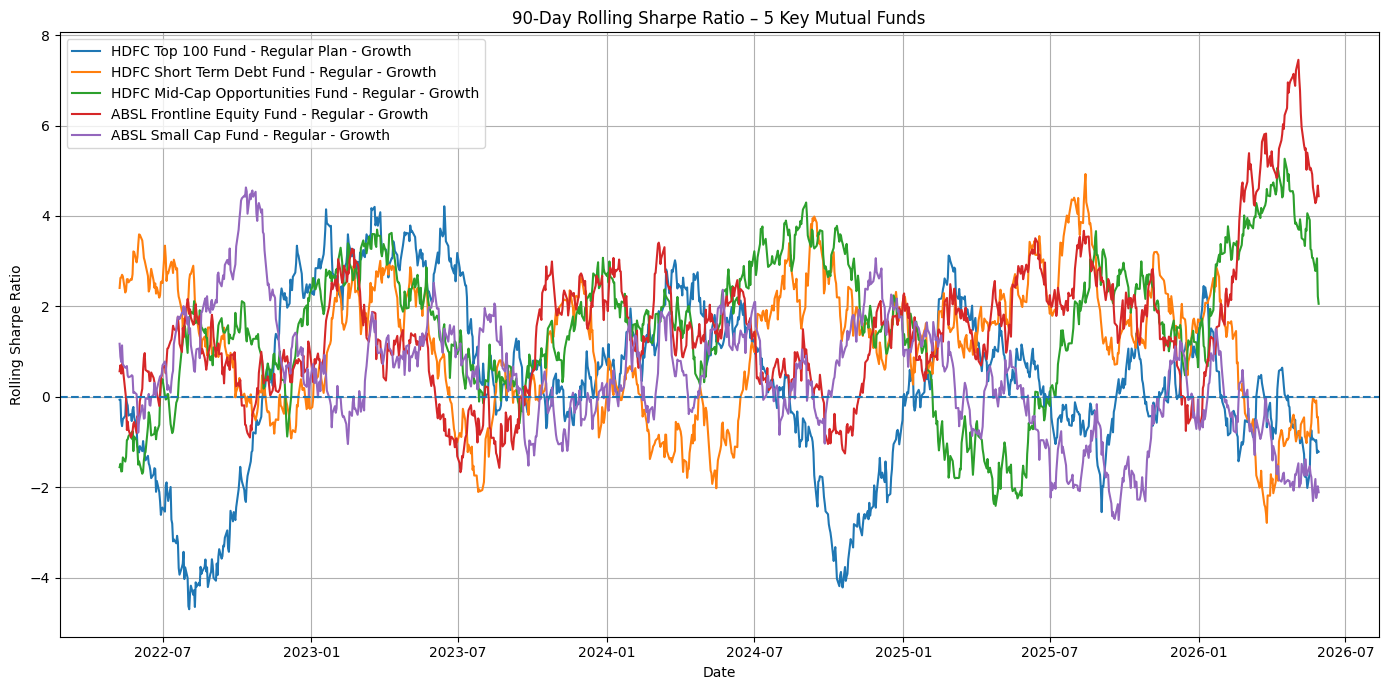

Task Completed Successfully!
Output saved as: /content/rolling_90_day_sharpe.csv
Graph saved as: /content/rolling_90_day_sharpe.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os # Import os module for directory operations

# ==============================
# 1. LOAD DATA
# ==============================

nav = pd.read_csv("/content/Cleaned_02_nav_history (1).csv")
fund_master = pd.read_csv("/content/Cleaned_01_data_fund_master.csv")

print(nav.head())
print(nav.columns)

# ==============================
# 2. CONVERT DATE
# ==============================

nav["date"] = pd.to_datetime(nav["date"])

# Sort data fund-wise and date-wise
nav = nav.sort_values(["amfi_code", "date"])

# ==============================
# 3. CALCULATE DAILY RETURNS
# ==============================

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# ==============================
# 4. CALCULATE 90-DAY ROLLING SHARPE
# Formula:
# Rolling Mean Return / Rolling Std Return * sqrt(252)
# ==============================

nav["rolling_90_sharpe"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(
           lambda x: (
               x.rolling(90).mean()
               / x.rolling(90).std()
           ) * np.sqrt(252)
       )
)

# ==============================
# 5. MERGE SCHEME NAMES
# ==============================

nav = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# ==============================
# 6. SELECT 5 KEY FUNDS
# Here we select first 5 funds
# You can change these later
# ==============================

key_funds = nav["amfi_code"].dropna().unique()[:5]

print("Selected 5 Fund Codes:")
print(key_funds)

# ==============================
# 7. FILTER DATA FOR 5 FUNDS
# ==============================

plot_data = nav[
    nav["amfi_code"].isin(key_funds)
].copy()

# ==============================
# 8. PLOT ROLLING 90-DAY SHARPE
# ==============================

plt.figure(figsize=(14, 7))

for fund in key_funds:

    fund_data = plot_data[
        plot_data["amfi_code"] == fund
    ].sort_values("date")

    fund_name = fund_data["scheme_name"].iloc[0]

    plt.plot(
        fund_data["date"],
        fund_data["rolling_90_sharpe"],
        label=fund_name
    )

plt.axhline(y=0, linestyle="--")

plt.title("90-Day Rolling Sharpe Ratio – 5 Key Mutual Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save graph to /content directory
plt.savefig(
    "/content/rolling_90_day_sharpe.png",
    dpi=300
)

plt.show()

# ==============================
# 9. SAVE RESULT
# ==============================

# Save CSV to /content directory
nav.to_csv(
    "/content/rolling_90_day_sharpe.csv",
    index=False
)

print("Task Completed Successfully!")
print("Output saved as: /content/rolling_90_day_sharpe.csv")
print("Graph saved as: /content/rolling_90_day_sharpe.png")

Shape: (32778, 13)

Columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

First 5 rows:
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra 

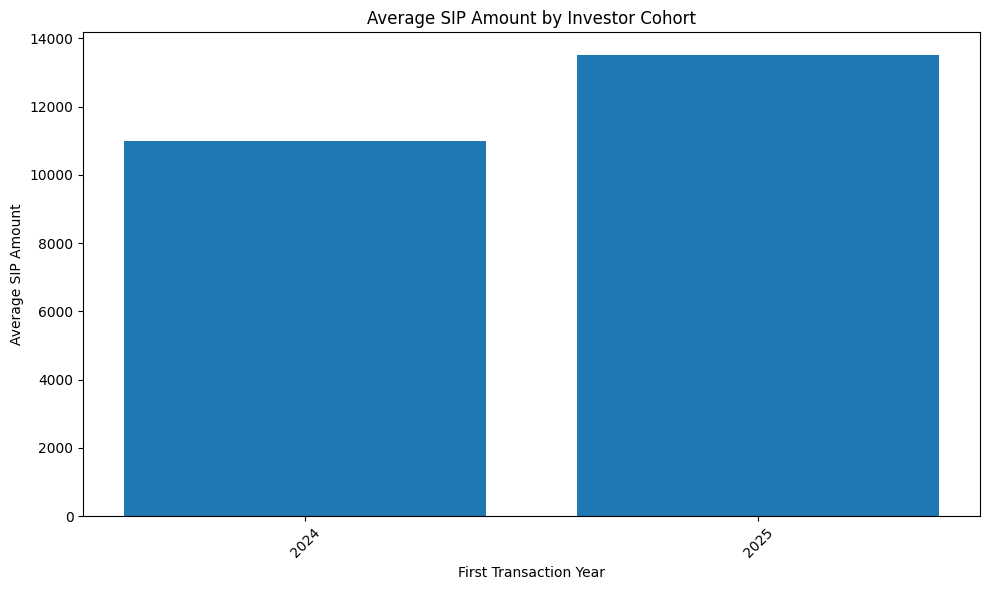

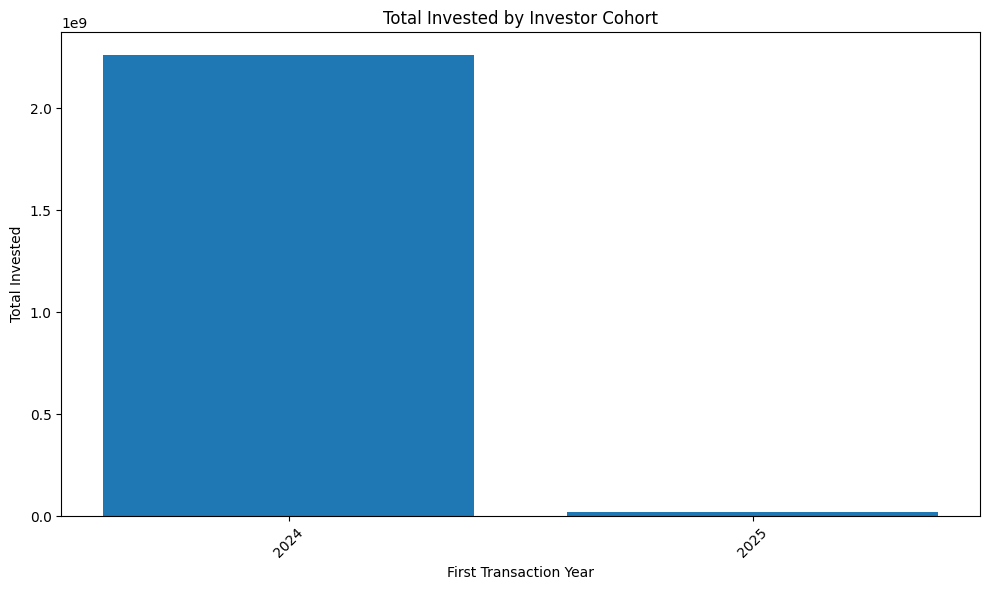

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv("/content/Cleaned_08_investor_transactions (1) (1).csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ==========================================
# 2. CONVERT DATE
# ==========================================

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

# Remove rows where date is missing
df = df.dropna(subset=["transaction_date"])


# ==========================================
# 3. FIND FIRST TRANSACTION YEAR
# ==========================================

first_transaction = (
    df.groupby("investor_id")["transaction_date"]
      .min()
      .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

print("\nInvestor Cohorts:")
print(first_transaction.head())


# ==========================================
# 4. ADD COHORT YEAR BACK TO TRANSACTIONS
# ==========================================

df = df.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)


# ==========================================
# 5. CLEAN TRANSACTION TYPE
# ==========================================

df["transaction_type"] = (
    df["transaction_type"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nTransaction Types:")
print(df["transaction_type"].value_counts())


# ==========================================
# 6. AVG SIP AMOUNT BY COHORT
# ==========================================

sip_data = df[
    df["transaction_type"].str.contains(
        "SIP",
        na=False
    )
]

avg_sip = (
    sip_data
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)


# ==========================================
# 7. TOTAL INVESTED BY COHORT
# ==========================================

# Investment transactions
investment_data = df[
    df["transaction_type"].isin(
        ["SIP", "LUMPSUM", "LUMP SUM", "LUMPSUM INVESTMENT"]
    )
]

total_invested = (
    investment_data
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)


# ==========================================
# 8. TOP FUND PREFERENCE
# ==========================================

fund_counts = (
    investment_data
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transaction_count")
)

top_funds = (
    fund_counts
    .sort_values(
        ["cohort_year", "transaction_count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_funds = top_funds.rename(
    columns={
        "amfi_code": "top_fund_amfi_code"
    }
)


# ==========================================
# 9. MERGE ALL COHORT METRICS
# ==========================================

cohort_analysis = (
    avg_sip
    .merge(
        total_invested,
        on="cohort_year",
        how="outer"
    )
    .merge(
        top_funds[
            [
                "cohort_year",
                "top_fund_amfi_code",
                "transaction_count"
            ]
        ],
        on="cohort_year",
        how="outer"
    )
)

# Sort by cohort year
cohort_analysis = cohort_analysis.sort_values(
    "cohort_year"
)


# ==========================================
# 10. DISPLAY RESULT
# ==========================================

print("\n======================================")
print("INVESTOR COHORT ANALYSIS")
print("======================================")

print(cohort_analysis)


# ==========================================
# 11. SAVE RESULT
# ==========================================

cohort_analysis.to_csv(
    "/content/investor_cohort_analysis.csv",
    index=False
)

print(
    "\nSaved: "
    "/content/investor_cohort_analysis.csv"
)


# ==========================================
# 12. VISUALIZATION - AVG SIP
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    cohort_analysis["cohort_year"].astype(str),
    cohort_analysis["avg_sip_amount"]
)

plt.title("Average SIP Amount by Investor Cohort")
plt.xlabel("First Transaction Year")
plt.ylabel("Average SIP Amount")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "/content/cohort_avg_sip.png",
    dpi=300
)

plt.show()


# ==========================================
# 13. VISUALIZATION - TOTAL INVESTED
# ==========================================

plt.figure(figsize=(10, 6))

plt.bar(
    cohort_analysis["cohort_year"].astype(str),
    cohort_analysis["total_invested"]
)

plt.title("Total Invested by Investor Cohort")
plt.xlabel("First Transaction Year")
plt.ylabel("Total Invested")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../content/cohort_total_invested.png",
    dpi=300
)

plt.show()

In [12]:
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv(
    "/content/Cleaned_08_investor_transactions (1) (1).csv"
)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


# ==========================================
# 2. CONVERT DATE
# ==========================================

df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

df = df.dropna(
    subset=["investor_id", "transaction_date"]
)


# ==========================================
# 3. KEEP ONLY SIP TRANSACTIONS
# ==========================================

df["transaction_type"] = (
    df["transaction_type"]
    .astype(str)
    .str.strip()
    .str.upper()
)

sip_df = df[
    df["transaction_type"].str.contains(
        "SIP",
        na=False
    )
].copy()

print("Total SIP transactions:", len(sip_df))


# ==========================================
# 4. SORT SIP TRANSACTIONS
# ==========================================

sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)


# ==========================================
# 5. COUNT SIP TRANSACTIONS PER INVESTOR
# ==========================================

sip_counts = (
    sip_df
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)


# ==========================================
# 6. KEEP INVESTORS WITH 6+ SIP TRANSACTIONS
# ==========================================

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
]["investor_id"]


sip_eligible = sip_df[
    sip_df["investor_id"].isin(
        eligible_investors
    )
].copy()


# ==========================================
# 7. CALCULATE GAP BETWEEN SIP DATES
# ==========================================

sip_eligible["gap_days"] = (
    sip_eligible
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)


# ==========================================
# 8. CALCULATE AVERAGE GAP
# ==========================================

continuity = (
    sip_eligible
    .groupby("investor_id")
    .agg(
        sip_transaction_count=(
            "transaction_date",
            "count"
        ),
        avg_gap_days=(
            "gap_days",
            "mean"
        ),
        max_gap_days=(
            "gap_days",
            "max"
        )
    )
    .reset_index()
)


# ==========================================
# 9. FLAG AT-RISK INVESTORS
# ==========================================

continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "at-risk",
    "regular"
)


# ==========================================
# 10. DISPLAY RESULT
# ==========================================

print("\n====================================")
print("SIP CONTINUITY ANALYSIS")
print("====================================")

print(continuity.head(20))


# ==========================================
# 11. SUMMARY
# ==========================================

print("\nStatus Summary:")
print(
    continuity["status"].value_counts()
)


# ==========================================
# 12. SAVE RESULT
# ==========================================

continuity.to_csv(
    "../content/sip_continuity_analysis.csv",
    index=False
)

print(
    "\nSaved successfully:"
    " content/sip_continuity_analysis.csv"
)

Shape: (32778, 13)
Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
Total SIP transactions: 19716

SIP CONTINUITY ANALYSIS
   investor_id  sip_transaction_count  avg_gap_days  max_gap_days   status
0    INV000004                      6     85.400000         265.0  at-risk
1    INV000008                      6     70.400000         165.0  at-risk
2    INV000010                      6     64.800000         139.0  at-risk
3    INV000011                      7     40.166667         125.0  at-risk
4    INV000012                      8     57.000000         132.0  at-risk
5    INV000013                      7     55.333333         104.0  at-risk
6    INV000014                      7     75.333333         128.0  at-risk
7    INV000023                      8     58.571429         115.0  at-risk
8    INV000028                      6     93.600000   

In [13]:
import pandas as pd

# ==========================================
# 1. LOAD FILES
# ==========================================

performance = pd.read_csv(
    "/content/Cleaned_07_scheme_performance (1) (1).csv"
)

fund_master = pd.read_csv(
    "/content/Cleaned_01_data_fund_master.csv"
)

print("Performance columns:")
print(performance.columns.tolist())

print("\nFund Master columns:")
print(fund_master.columns.tolist())


# ==========================================
# 2. CHECK SHARPE COLUMN
# ==========================================

print("\nPerformance sample:")
print(performance.head())


# ==========================================
# 3. MERGE FUND INFORMATION
# ==========================================

df = performance.merge(
    fund_master,
    on="amfi_code",
    how="left",
    suffixes=("_performance", "_master")
)


# ==========================================
# 4. DISPLAY IMPORTANT COLUMNS
# ==========================================

print("\nMerged columns:")
print(df.columns.tolist())


# ==========================================
# 5. USER INPUT
# ==========================================

risk = input(
    "\nEnter risk appetite (Low / Moderate / High): "
).strip().lower()


# ==========================================
# 6. VALIDATE INPUT
# ==========================================

valid_risks = ["low", "moderate", "high"]

if risk not in valid_risks:
    print(
        "Invalid risk appetite! "
        "Please enter Low, Moderate or High."
    )
else:

    # ======================================
    # 7. FIND RISK COLUMN
    # ======================================

    if "risk_grade" in df.columns:
        risk_column = "risk_grade"

    elif "risk_category" in df.columns:
        risk_column = "risk_category"

    elif "risk_grade_master" in df.columns:
        risk_column = "risk_grade_master"

    elif "risk_category_master" in df.columns:
        risk_column = "risk_category_master"

    else:
        raise ValueError(
            "Risk grade/category column not found."
        )


    # ======================================
    # 8. CLEAN RISK VALUES
    # ======================================

    df[risk_column] = (
        df[risk_column]
        .astype(str)
        .str.strip()
        .str.lower()
    )


    # ======================================
    # 9. FIND SHARPE COLUMN
    # ======================================

    if "sharpe_ratio" in df.columns:
        sharpe_column = "sharpe_ratio"

    elif "sharpe" in df.columns:
        sharpe_column = "sharpe"

    else:
        raise ValueError(
            "Sharpe Ratio column not found."
        )


    # ======================================
    # 10. FILTER BY RISK
    # ======================================

    matching_funds = df[
        df[risk_column] == risk
    ].copy()


    # ======================================
    # 11. REMOVE MISSING SHARPE VALUES
    # ======================================

    matching_funds[sharpe_column] = pd.to_numeric(
        matching_funds[sharpe_column],
        errors="coerce"
    )

    matching_funds = matching_funds.dropna(
        subset=[sharpe_column]
    )


    # ======================================
    # 12. SORT BY SHARPE RATIO
    # ======================================

    matching_funds = matching_funds.sort_values(
        by=sharpe_column,
        ascending=False
    )


    # ======================================
    # 13. TOP 3 FUNDS
    # ======================================

    top_3 = matching_funds.head(3).copy()


    # ======================================
    # 14. CREATE RANK
    # ======================================

    top_3.insert(
        0,
        "Rank",
        range(1, len(top_3) + 1)
    )


    # ======================================
    # 15. FIND FUND NAME COLUMN
    # ======================================

    if "scheme_name" in top_3.columns:
        fund_name_column = "scheme_name"

    elif "scheme_name_master" in top_3.columns:
        fund_name_column = "scheme_name_master"

    elif "scheme_name_performance" in top_3.columns:
        fund_name_column = "scheme_name_performance"

    else:
        fund_name_column = "amfi_code"


    # ======================================
    # 16. RECOMMENDATION TABLE
    # ======================================

    recommendation = top_3[
        [
            "Rank",
            "amfi_code",
            fund_name_column,
            risk_column,
            sharpe_column
        ]
    ].copy()


    recommendation.columns = [
        "Rank",
        "AMFI Code",
        "Fund Name",
        "Risk Grade",
        "Sharpe Ratio"
    ]


    # ======================================
    # 17. PRINT RECOMMENDATIONS
    # ======================================

    print("\n")
    print("=" * 70)
    print("        SIMPLE MUTUAL FUND RECOMMENDER")
    print("=" * 70)

    print(
        f"\nRisk Appetite Selected: "
        f"{risk.title()}"
    )

    print("\nTop 3 Recommended Funds:\n")

    print(
        recommendation.to_string(
            index=False
        )
    )

    print("\n" + "=" * 70)


    # ======================================
    # 18. SAVE RECOMMENDATIONS
    # ======================================

    recommendation.to_csv(
        "/content/fund_recommendations.csv",
        index=False
    )

    print(
        "\nRecommendation saved to:"
        " content/fund_recommendations.csv"
    )

Performance columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'anomaly_flag']

Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Performance sample:
   amfi_code                                    scheme_name  \
0     101206  Absl Frontline Equity Fund - Regular - Growth   
1     101208            Absl Liquid Fund - Regular - Growth   
2     101207         Absl Small Cap Fund - Regular - Growth   
3     119092          Axis Bluechip Fund - Regular - Growth   
4     119093           Axis Bluechip Fund - Direct - Growth   

    

Holdings columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

Holdings sample:
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08   

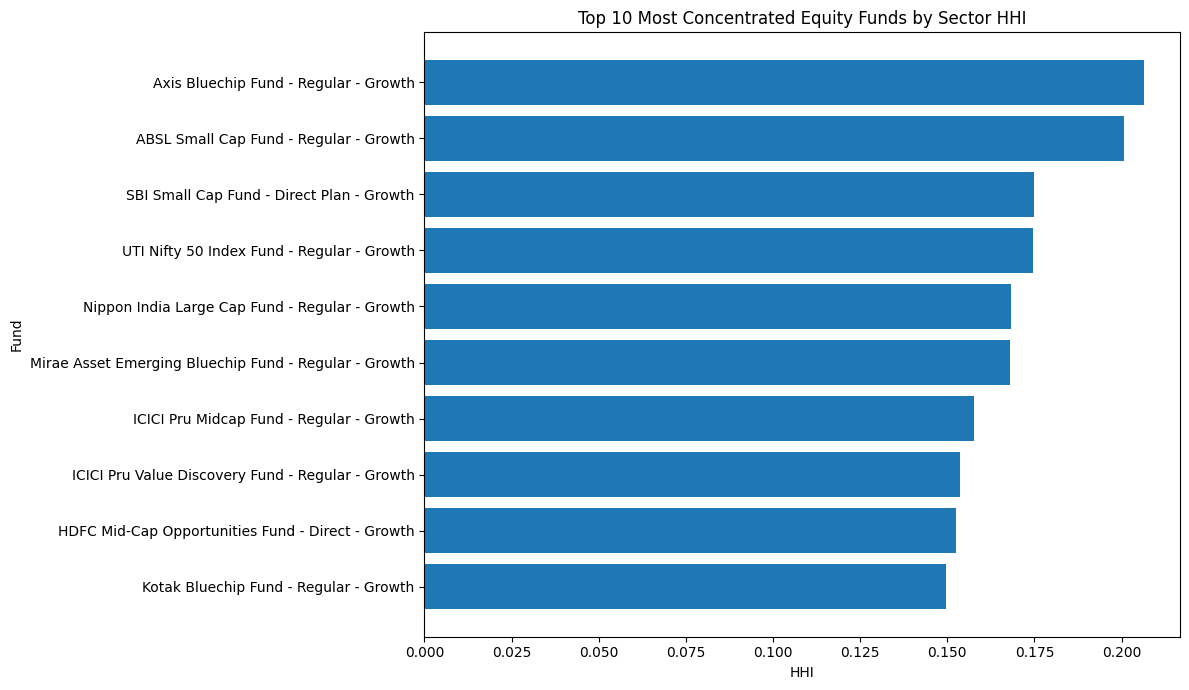

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA
# ==========================================

holdings = pd.read_csv(
    "/content/09_portfolio_holdings.csv"
)

fund_master = pd.read_csv(
    "/content/Cleaned_01_data_fund_master.csv"
)

print("Holdings columns:")
print(holdings.columns.tolist())

print("\nFund Master columns:")
print(fund_master.columns.tolist())


# ==========================================
# 2. CHECK DATA
# ==========================================

print("\nHoldings sample:")
print(holdings.head())


# ==========================================
# 3. FIND WEIGHT COLUMN
# ==========================================

if "weight" in holdings.columns:
    weight_column = "weight"

elif "weight_pct" in holdings.columns:
    weight_column = "weight_pct"

elif "weight_percentage" in holdings.columns:
    weight_column = "weight_percentage"

else:
    raise ValueError(
        "Weight column not found."
    )


# ==========================================
# 4. CONVERT WEIGHT TO NUMERIC
# ==========================================

holdings[weight_column] = pd.to_numeric(
    holdings[weight_column],
    errors="coerce"
)

holdings = holdings.dropna(
    subset=["amfi_code", weight_column]
)


# ==========================================
# 5. CHECK WHETHER WEIGHTS ARE %
# ==========================================

print(
    "\nMaximum weight:",
    holdings[weight_column].max()
)

# If weights are like 30, 25, 10
# convert them into 0.30, 0.25, 0.10

if holdings[weight_column].max() > 1:
    holdings["weight_decimal"] = (
        holdings[weight_column] / 100
    )
else:
    holdings["weight_decimal"] = (
        holdings[weight_column]
    )


# ==========================================
# 6. CALCULATE HHI
# ==========================================

hhi = (
    holdings
    .groupby("amfi_code")["weight_decimal"]
    .apply(
        lambda x: (x ** 2).sum()
    )
    .reset_index(name="HHI")
)


# ==========================================
# 7. MERGE FUND NAMES
# ==========================================

result = hhi.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],
    on="amfi_code",
    how="left"
)


# ==========================================
# 8. FILTER EQUITY FUNDS
# ==========================================

result["category"] = (
    result["category"]
    .astype(str)
    .str.strip()
    .str.lower()
)

equity_funds = result[
    result["category"].str.contains(
        "equity",
        na=False
    )
].copy()


# ==========================================
# 9. SORT BY HHI
# ==========================================

equity_funds = equity_funds.sort_values(
    "HHI",
    ascending=False
)


# ==========================================
# 10. ADD CONCENTRATION LEVEL
# ==========================================

equity_funds["concentration"] = pd.cut(
    equity_funds["HHI"],
    bins=[
        -np.inf,
        0.10,
        0.18,
        np.inf
    ],
    labels=[
        "Low",
        "Moderate",
        "High"
    ]
)


# ==========================================
# 11. DISPLAY RESULT
# ==========================================

print("\n==========================================")
print("SECTOR HHI CONCENTRATION - EQUITY FUNDS")
print("==========================================")

print(
    equity_funds[
        [
            "amfi_code",
            "scheme_name",
            "HHI",
            "concentration"
        ]
    ].to_string(index=False)
)


# ==========================================
# 12. SAVE RESULT
# ==========================================

equity_funds.to_csv(
    "/content/sector_hhi_concentration.csv",
    index=False
)

print(
    "\nSaved successfully:"
    " /content/sector_hhi_concentration.csv"
)


# ==========================================
# 13. TOP 10 MOST CONCENTRATED FUNDS
# ==========================================

top_10 = equity_funds.head(10)

print("\nTop 10 Most Concentrated Equity Funds:")

print(
    top_10[
        [
            "scheme_name",
            "HHI",
            "concentration"
        ]
    ].to_string(index=False)
)


# ==========================================
# 14. VISUALIZATION
# ==========================================

plt.figure(figsize=(12, 7))

plt.barh(
    top_10["scheme_name"],
    top_10["HHI"]
)

plt.xlabel("HHI")
plt.ylabel("Fund")
plt.title(
    "Top 10 Most Concentrated Equity Funds by Sector HHI"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "/content/sector_hhi_concentration.png",
    dpi=300
)

plt.show()

# Advanced Investment Insights

## 1. Fund Risk: VaR Analysis

The Historical Value at Risk (VaR) analysis identifies the funds with the highest downside risk at the 95% confidence level. Funds with a more negative VaR are exposed to larger potential daily losses under normal market conditions.

The funds with the highest downside risk should therefore be considered more volatile and may require greater risk tolerance from investors.

**Key Insight:** Funds with the most negative 95% VaR should be treated as higher-risk investments compared with funds having less negative VaR.

---

## 2. Investor Cohort Investment Behaviour

Investor cohort analysis groups investors according to their first transaction year. The analysis compares average SIP investment and total investment across different cohorts.

The cohort with the highest total invested amount represents the strongest contribution to the portfolio from a particular investor-generation, while the cohort with the highest average SIP amount indicates stronger recurring investment behaviour.

**Key Insight:** Comparing cohorts helps identify which investor generations contribute the most capital and which cohorts demonstrate stronger SIP investment behaviour.

---

## 3. SIP Continuity and At-Risk Investors

SIP continuity analysis considers investors with at least six SIP transactions and measures the average number of days between consecutive SIP investments.

Investors with an average SIP gap greater than 35 days are classified as **"at-risk"**, indicating weaker SIP continuity and a higher possibility of discontinuing their recurring investments.

**Key Insight:** A high proportion of at-risk investors may indicate potential SIP churn and highlights the need for investor-retention strategies.

---

## 4. Risk-Adjusted Fund Performance

The fund recommender ranks funds within each risk category using their Sharpe Ratio. A higher Sharpe Ratio indicates better risk-adjusted performance because the fund generates higher returns relative to its volatility.

The top three funds within each risk category can therefore be considered stronger candidates for investors with the corresponding risk appetite.

**Key Insight:** Investors should not evaluate funds only by absolute returns; Sharpe Ratio provides a better view of whether the additional return adequately compensates for the risk taken.

---

## 5. Portfolio Concentration: Sector HHI

The Herfindahl-Hirschman Index (HHI) measures sector concentration within equity fund portfolios. A higher HHI indicates that a fund's portfolio is concentrated in fewer sectors, while a lower HHI indicates greater sector diversification.

Funds with high HHI values may be more sensitive to adverse developments in their dominant sectors.

**Key Insight:** Comparing HHI across equity funds helps identify highly concentrated portfolios and distinguish them from more diversified funds.

In [24]:
import pandas as pd
import os


# ============================================================
# 1. FILE PATHS
# ============================================================

FUND_MASTER_PATH = "/content/Cleaned_01_data_fund_master.csv"
PERFORMANCE_PATH = "/content/Cleaned_07_scheme_performance (1) (1).csv"


# ============================================================
# 2. LOAD DATA
# ============================================================

def load_data():

    print("Loading mutual fund data...")

    fund_master = pd.read_csv(FUND_MASTER_PATH)
    performance = pd.read_csv(PERFORMANCE_PATH)

    print(f"Fund Master: {len(fund_master)} records")
    print(f"Performance: {len(performance)} records")

    return fund_master, performance


# ============================================================
# 3. PREPARE DATA
# ============================================================

def prepare_data(fund_master, performance):

    # Merge fund information with performance metrics
    df = pd.merge(
        fund_master,
        performance,
        on="amfi_code",
        how="inner",
        suffixes=('_master', '_performance') # Add suffixes to distinguish common columns
    )

    # Remove duplicate funds if any
    df = df.drop_duplicates(subset=["amfi_code"])

    return df


# ============================================================
# 4. NORMALIZE VALUES
# ============================================================

def normalize(series):

    series = pd.to_numeric(series, errors="coerce")

    min_value = series.min()
    max_value = series.max()

    if max_value == min_value:
        return pd.Series(1, index=series.index)

    return (series - min_value) / (max_value - min_value)


# ============================================================
# 5. CALCULATE FUND SCORE
# ============================================================

def calculate_score(df):

    print("\nCalculating fund scores...")

    # Make sure numerical columns are numeric
    numeric_columns = [
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct_performance",
        "max_drawdown_pct"
    ]

    for column in numeric_columns:

        if column in df.columns:
            df[column] = pd.to_numeric(
                df[column],
                errors="coerce"
            )

    # --------------------------------------------------------
    # Positive factors
    # Higher value = better
    # --------------------------------------------------------

    df["return_score"] = normalize(df["return_3yr_pct"])

    df["sharpe_score"] = normalize(df["sharpe_ratio"])

    df["alpha_score"] = normalize(df["alpha"])


    # --------------------------------------------------------
    # Negative factors
    # Lower value = better
    # --------------------------------------------------------

    df["expense_score"] = 1 - normalize(
        df["expense_ratio_pct_performance"]
    )

    df["drawdown_score"] = 1 - normalize(
        abs(df["max_drawdown_pct"])
    )


    # --------------------------------------------------------
    # Composite Score
    # --------------------------------------------------------

    df["fund_score"] = (

        0.30 * df["return_score"]

        + 0.25 * df["sharpe_score"]

        + 0.20 * df["alpha_score"]

        + 0.15 * df["expense_score"]

        + 0.10 * df["drawdown_score"]
    )

    # Convert score to 0-100
    df["fund_score"] = df["fund_score"] * 100

    return df


# ============================================================
# 6. RISK PROFILE FILTER
# ============================================================

def filter_by_risk(df, risk_profile):

    risk_profile = risk_profile.lower()

    if risk_profile == "low":

        # Conservative investors
        filtered = df[
            df["risk_category"]
            .astype(str)
            .str.lower()
            .isin([
                "low",
                "low risk",
                "moderately low"
            ])
        ]

    elif risk_profile == "moderate":

        filtered = df[
            df["risk_category"]
            .astype(str)
            .str.lower()
            .isin([
                "moderate",
                "moderately high"
            ])
        ]

    elif risk_profile == "high":

        filtered = df[
            df["risk_category"]
            .astype(str)
            .str.lower()
            .isin([
                "high",
                "very high"
            ])
        ]

    else:

        print("Invalid risk profile.")
        print("Choose: low / moderate / high")

        return pd.DataFrame()

    return filtered


# ============================================================
# 7. RECOMMEND FUNDS
# ============================================================

def recommend_funds(df, risk_profile, top_n=5):

    filtered_df = filter_by_risk(
        df,
        risk_profile
    )

    if filtered_df.empty:

        print(
            "\nNo funds found for this risk profile."
        )

        return filtered_df

    # Sort according to fund score
    recommendations = filtered_df.sort_values(
        by="fund_score",
        ascending=False
    )

    recommendations = recommendations.head(top_n)

    return recommendations


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

def display_recommendations(recommendations):

    if recommendations.empty:
        return

    print("\n" + "=" * 80)

    print("              TOP MUTUAL FUND RECOMMENDATIONS")

    print("=" * 80)

    columns_to_show = [
        "scheme_name",
        "category",
        "risk_category",
        "return_3yr_pct",
        "sharpe_ratio",
        "alpha",
        "expense_ratio_pct_performance",
        "max_drawdown_pct",
        "fund_score"
    ]

    # Show only columns which actually exist
    available_columns = [
        col
        for col in columns_to_show
        if col in recommendations.columns
    ]

    result = recommendations[available_columns].copy()

    print(
        result.to_string(
            index=False
        )
    )

    print("=" * 80)


# ============================================================
# 9. SAVE RECOMMENDATIONS
# ============================================================

def save_recommendations(
    recommendations,
    risk_profile
):

    output_directory = "content"

    os.makedirs(
        output_directory,
        exist_ok=True
    )

    output_file = (
        f"{output_directory}/"
        f"recommendations_{risk_profile}.csv"
    )

    recommendations.to_csv(
        output_file,
        index=False
    )

    print(
        f"\nRecommendations saved to:"
    )

    print(output_file)


# ============================================================
# 10. MAIN PROGRAM
# ============================================================

def main():

    # Load data
    fund_master, performance = load_data()

    # Prepare data
    df = prepare_data(
        fund_master,
        performance
    )

    # Calculate score
    df = calculate_score(df)

    # Ask user risk profile
    print("\nChoose your risk profile:")

    print("1. Low")
    print("2. Moderate")
    print("3. High")

    choice = input(
        "\nEnter your choice (1/2/3): "
    )

    if choice == "1":

        risk_profile = "low"

    elif choice == "2":

        risk_profile = "moderate"

    elif choice == "3":

        risk_profile = "high"

    else:

        print("\nInvalid choice.")

        return

    # Generate recommendations
    recommendations = recommend_funds(
        df,
        risk_profile,
        top_n=5
    )

    # Display results
    display_recommendations(
        recommendations
    )

    # Save results
    save_recommendations(
        recommendations,
        risk_profile
    )


# ============================================================
# RUN PROGRAM
# ============================================================

if __name__ == "__main__":
    main()

Loading mutual fund data...
Fund Master: 40 records
Performance: 40 records

Calculating fund scores...

Choose your risk profile:
1. Low
2. Moderate
3. High

Enter your choice (1/2/3): 1

              TOP MUTUAL FUND RECOMMENDATIONS
risk_category  return_3yr_pct  sharpe_ratio  alpha  expense_ratio_pct_performance  max_drawdown_pct  fund_score
          Low            7.68          7.68   1.85                           0.74             -2.62   69.667236
          Low            6.18          6.18   1.52                           0.60             -3.81   58.807154
          Low            7.37          1.84   1.98                           0.56             -6.01   51.098382
          Low            5.14          5.14   1.18                           0.79             -3.66   46.125935
          Low            6.07          1.52   1.60                           0.77             -2.30   40.925070

Recommendations saved to:
content/recommendations_low.csv
